# Application 3 — E-commerce Customer Behavior & Interest Discovery

## 1. Problem definition
**Objective.** Using a customer's product rating, demographic/behavioural signal
(age, positive-feedback count), the product's catalogue category (division/department/
class), **and the free-text review the customer wrote**, predict whether the customer
*recommends* the product to other customers — a direct, first-party signal of product
**interest/preference/satisfaction** that an e-commerce platform can act on (e.g. surfacing
recommended items more prominently, or flagging products whose reviews look positive in
text but are miscategorised).

We define:

$$X = \text{customer behavioural/tabular features} + \text{text representation of the review}$$
$$y = \texttt{Recommended IND} \in \{0, 1\}$$

This is a **binary classification** problem, and — unlike Applications 1–2 — the raw
input is **heterogeneous**: part tabular, part free text, so it needs two different
representation techniques combined into one feature vector (Part 12).


## 2. Dataset source
- **Dataset:** Women's E-Commerce Clothing Reviews
- **Kaggle URL:** https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
- 23,486 real, anonymised customer reviews of a women's clothing retailer (company name
  redacted to "retailer" by the original publisher).
- Mirrored for an offline-reproducible download from
  `https://raw.githubusercontent.com/AFAgarap/ecommerce-reviews-analysis/master/Womens%20Clothing%20E-Commerce%20Reviews.csv`
  (identical 23,486×10 table).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)
import joblib, json, os, sys

sys.path.insert(0, os.path.abspath('..'))
from common import NUMERIC, CATEGORICAL, TEXT_COL, TABULAR_FEATURES, FEATURE_ORDER, TARGET, TextCleaner

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


In [2]:
df = pd.read_csv('../data/ecommerce_raw.csv', index_col=0)
print('Original dataframe shape:', df.shape)
df.head(3)


Original dataframe shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


## 3–4. Dataset inspection

In [3]:
df.shape

(23486, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class Name,23472,20,Dresses,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5–7. Data-quality analysis

In [6]:
print('Missing values per column:')
print(df.isna().sum())
print()
print('Duplicated rows:', df.duplicated().sum())


Missing values per column:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64



Duplicated rows: 21


**Explanation.**
- `Title` is missing for 3,810 reviews (16.2%) — many customers simply did not write a
  title; treated as optional and not used as a model feature.
- `Review Text` is missing for 845 reviews (3.6%) — customers who rated without commenting;
  handled by `TextCleaner` (→ empty string, Part 15) rather than dropped, since the
  tabular features for those rows are still valid and usable.
- `Division/Department/Class Name` are each missing for the same 14 rows — a negligible
  0.06% of the data; these rows are dropped for the categorical branch (Part 15's imputer
  additionally guards against any missing categorical value with a `most_frequent`
  fallback).
- No duplicated rows.


## 8. Invalid-value analysis

In [7]:
print('Rating range:', df['Rating'].min(), '-', df['Rating'].max(), ' (expected 1-5)')
print('Recommended IND unique values:', sorted(df['Recommended IND'].unique()))
print('Age range:', df['Age'].min(), '-', df['Age'].max())
print('Positive Feedback Count range:', df['Positive Feedback Count'].min(), '-', df['Positive Feedback Count'].max())
print()
print('Class Name value counts (checking for inconsistent/typo categories):')
print(df['Class Name'].value_counts(dropna=False))


Rating range: 1 - 5  (expected 1-5)
Recommended IND unique values: [np.int64(0), np.int64(1)]
Age range: 18 - 99
Positive Feedback Count range: 0 - 122

Class Name value counts (checking for inconsistent/typo categories):
Class Name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
NaN                 14
Casual bottoms       2
Chemises             1
Name: count, dtype: int64


**Interpretation.** `Rating` (1–5) and `Recommended IND` (0/1) are both within their
valid ranges — no invalid values. `Age` (18–99) is plausible for a clothing retailer's
customer base. `Class Name` has 20 legitimate categories with no obvious typos/duplicates
(e.g. no "Dress" vs "Dresses" inconsistency), though two categories (`Casual bottoms`:2,
`Chemises`:1) are extremely rare — these are kept (not merged) since `OneHotEncoder`
handles rare/unseen categories gracefully via `handle_unknown='ignore'`.

## 9. Outlier analysis

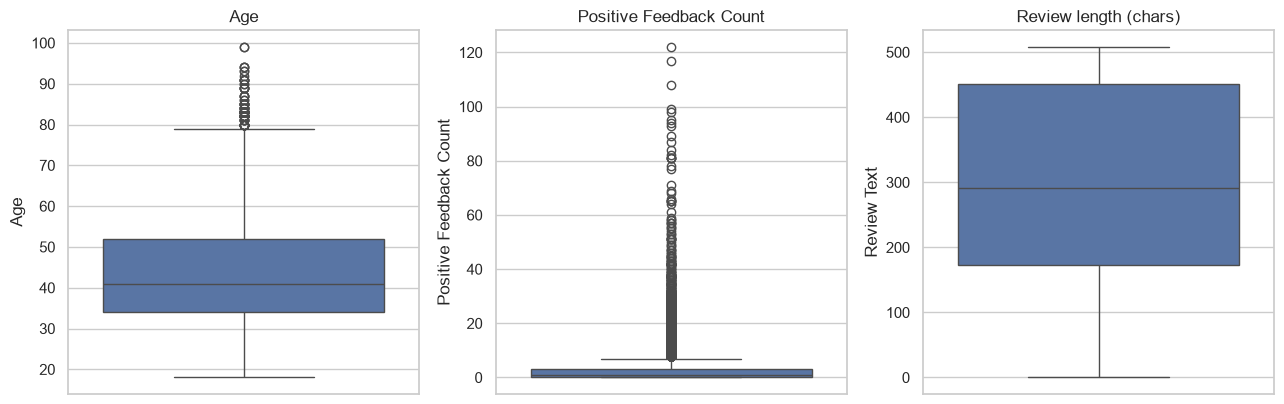

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
sns.boxplot(y=df['Age'], ax=axes[0], color='#4C72B0'); axes[0].set_title('Age')
sns.boxplot(y=df['Positive Feedback Count'], ax=axes[1], color='#4C72B0'); axes[1].set_title('Positive Feedback Count')
sns.boxplot(y=df['Review Text'].fillna('').str.len(), ax=axes[2], color='#4C72B0'); axes[2].set_title('Review length (chars)')
plt.tight_layout()
plt.show()


**Observation.** `Positive Feedback Count` is heavily right-skewed (most reviews get
0 "helpful" votes, a few get dozens); review length also has a long right tail (a handful
of very long reviews).
**Interpretation.** These are genuine behavioural patterns (most reviews are simply never
up-voted; most customers write short reviews), not data-entry errors.
**ML implication.** No values are removed as outliers; `StandardScaler` still benefits
`Positive Feedback Count`/`Age` for the linear models, and tree ensembles are naturally
robust to this skew.

## 10. Exploratory Data Analysis

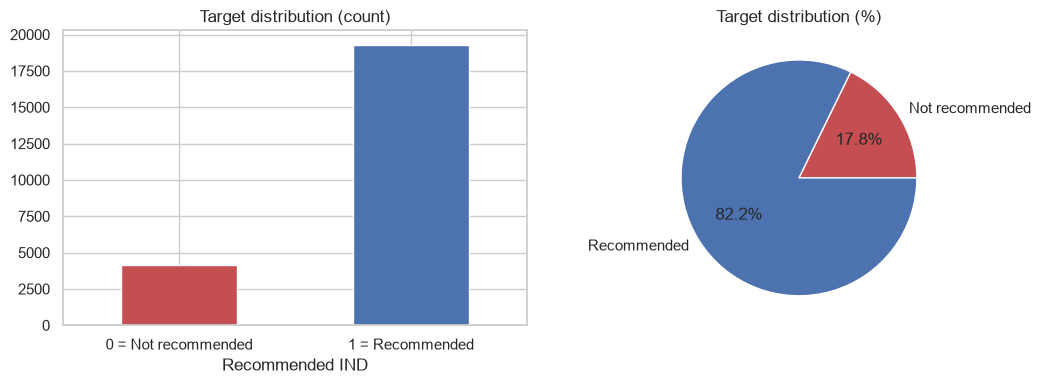

Recommended IND
1    19314
0     4172
Name: count, dtype: int64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['Recommended IND'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color=['#C44E52','#4C72B0'])
ax[0].set_xticklabels(['0 = Not recommended','1 = Recommended'], rotation=0)
ax[0].set_title('Target distribution (count)')
df['Recommended IND'].value_counts().sort_index().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
    labels=['Not recommended','Recommended'], colors=['#C44E52','#4C72B0'])
ax[1].set_ylabel(''); ax[1].set_title('Target distribution (%)')
plt.tight_layout()
plt.show()
print(df['Recommended IND'].value_counts())


**Observation:** 19,314 reviews (82.2%) recommend the product, only 4,172 (17.8%) do
not. **Interpretation:** the classes are meaningfully imbalanced (≈4.6:1) — most shoppers
who bother to write a review liked what they bought. **ML implication:** a
majority-class baseline already scores 82.2% accuracy, so Accuracy alone is a poor
model-selection metric here; we rely on Precision/Recall/F1/ROC-AUC for the minority
("not recommended") class, and use **stratified** splitting throughout.

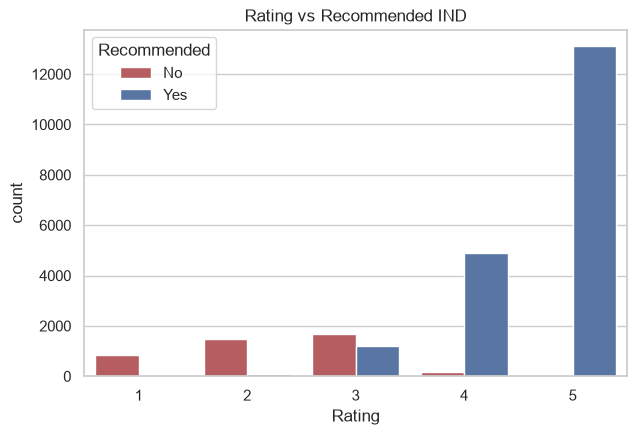

In [10]:
plt.figure(figsize=(7, 4.5))
sns.countplot(data=df, x='Rating', hue='Recommended IND', palette=['#C44E52','#4C72B0'])
plt.title('Rating vs Recommended IND')
plt.legend(title='Recommended', labels=['No','Yes'])
plt.show()


**Observation:** almost no 1–2-star reviews are "recommended", almost all 5-star
reviews are. 3-star reviews are the only genuinely mixed group.
**Interpretation:** `Rating` alone is an extremely strong (near-deterministic) predictor
of `Recommended IND` — both are self-reported by the same customer at the same time, so
this is a very easy majority of the signal, not model leakage (the label being predicted
is a *distinct* field the customer explicitly filled in, not derived from Rating by any
data-processing rule).
**ML implication:** since `Rating` will dominate, the *interesting* research question
becomes whether **text** captures additional signal beyond `Rating` for the harder,
ambiguous 3-star cases — directly investigated by the tabular-vs-text ablation in
Part 19.

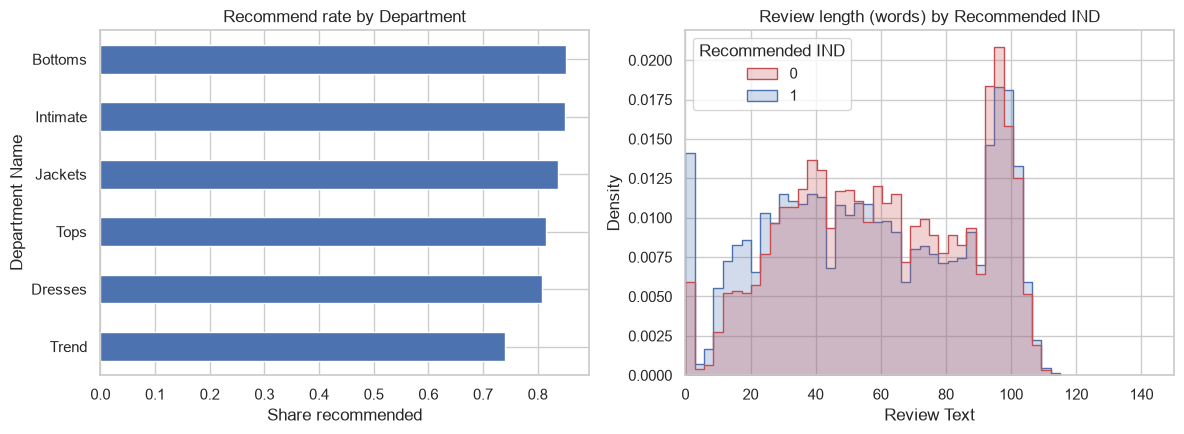

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
dept_rate = df.groupby('Department Name')['Recommended IND'].mean().sort_values()
dept_rate.plot(kind='barh', ax=ax[0], color='#4C72B0')
ax[0].set_xlabel('Share recommended'); ax[0].set_title('Recommend rate by Department')

review_len = df['Review Text'].fillna('').str.split().apply(len)
sns.histplot(x=review_len, hue=df['Recommended IND'], bins=40, ax=ax[1],
             palette=['#C44E52','#4C72B0'], element='step', stat='density', common_norm=False)
ax[1].set_title('Review length (words) by Recommended IND')
ax[1].set_xlim(0, 150)
plt.tight_layout()
plt.show()


**Observation (left):** recommend-rate varies by department — `Trend` items are
recommended least often, `Jackets`/`Intimate` most often.
**Observation (right):** non-recommended reviews (red) skew slightly longer on average
than recommended ones (blue) — dissatisfied customers tend to explain themselves at
more length.
**Interpretation:** product category carries real, if modest, additional signal; review
*length* alone is a weak but non-zero behavioural proxy for dissatisfaction.
**ML implication:** both `Department Name` (categorical, one-hot) and the full text of
the review (not just its length) are worth including as model inputs.

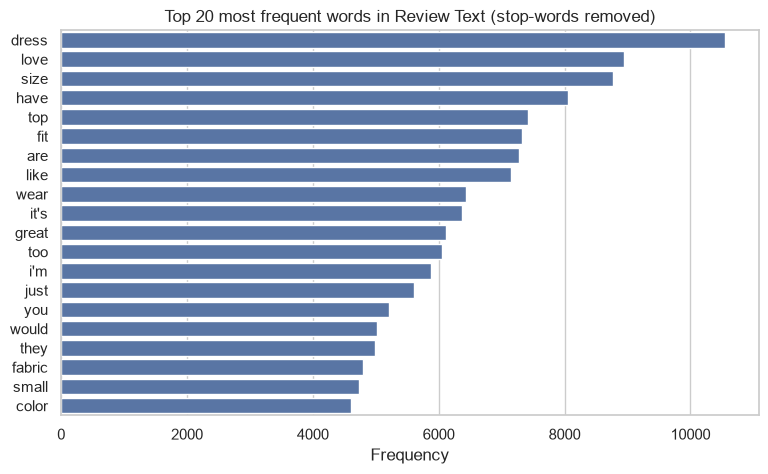

In [12]:
all_words = Counter()
stop_words = set('the a an is it this that i and to of in for was with on but as my not so very'.split())
for txt in df['Review Text'].dropna():
    words = re.findall(r"[a-zA-Z']+", txt.lower())
    all_words.update(w for w in words if w not in stop_words and len(w) > 2)

top20 = all_words.most_common(20)
words_, counts_ = zip(*top20)
plt.figure(figsize=(9, 5))
sns.barplot(x=list(counts_), y=list(words_), color='#4C72B0')
plt.title('Top 20 most frequent words in Review Text (stop-words removed)')
plt.xlabel('Frequency')
plt.show()


**Observation:** the most frequent content words are `dress`, `size`, `top`, `love`,
`fit`, `like`, `fabric`, `great` — a mix of garment-type nouns, fit/sizing vocabulary, and
sentiment words.
**Interpretation:** reviews genuinely discuss *product interest and fit*, not generic
filler text — this is exactly the kind of vocabulary a bag-of-words/TF-IDF representation
can exploit (Part 15).
**ML implication:** confirms text carries topical + sentiment information distinct from
the numeric `Rating`, motivating its inclusion via `TfidfVectorizer`.

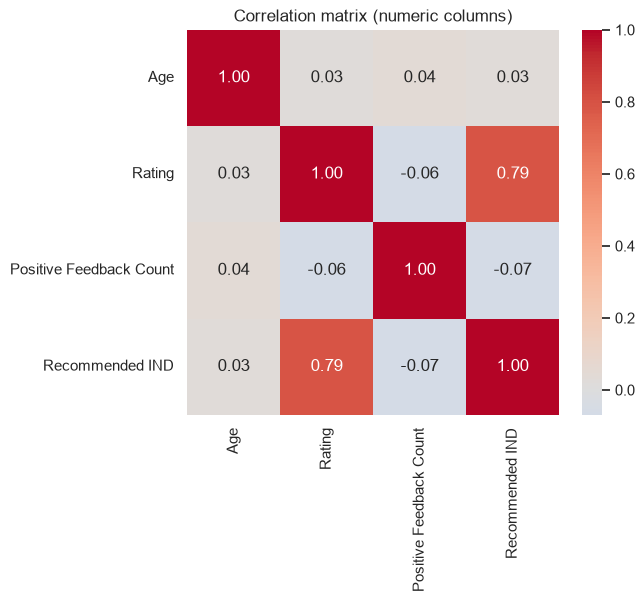

In [13]:
plt.figure(figsize=(6, 5))
corr = df[['Age','Rating','Positive Feedback Count','Recommended IND']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric columns)')
plt.show()


**Observation:** `Rating` correlates strongly with `Recommended IND` (r≈0.79, as
expected from Part 10); `Age` and `Positive Feedback Count` correlate only weakly with
the target (|r|<0.06).
**Interpretation:** the numeric behavioural columns beyond `Rating` carry little
*independent* linear signal — most of the discriminative power will come from `Rating`,
the categorical product fields, and the free text.
**ML implication:** keep `Age`/`Positive Feedback Count` (cheap, harmless, occasionally
useful in non-linear models) but do not expect them to dominate feature importance.

## 11. Feature types

| Feature | Type | Meaning |
|---|---|---|
| Age | Numerical (continuous) | Customer's age |
| Rating | Numerical (ordinal, 1–5) | Star rating given by the customer |
| Positive Feedback Count | Numerical (count) | How many other users found the review helpful |
| Division Name | Categorical (3 classes) | Top-level catalogue division |
| Department Name | Categorical (6 classes) | Product department |
| Class Name | Categorical (20 classes) | Fine-grained product class |
| **Review Text** | **Free text** | Customer's written review (raw natural language) |
| **Recommended IND** | **Target (binary)** | 1 = customer recommends the product, 0 = does not |

This is the only application with a genuine **text column**, so it is the only one that
needs the `Text → Tokens → Token IDs → Vector/Embedding` pipeline from Lecture 02 /
Part IV of the assignment, in addition to the tabular feature-vector representation used
by Applications 1–2.


## 12. Data Representation

$$x_i = \underbrace{[\text{Age}, \text{Rating}, \text{PositiveFeedbackCount}]}_{\text{numeric}}
\oplus \underbrace{[\text{Division}, \text{Department}, \text{Class}]_{\text{one-hot}}}_{\text{categorical}}
\oplus \underbrace{\text{tfidf}(\text{ReviewText})}_{\text{text vector} \in \mathbb{R}^{d_{\text{text}}}}$$


In [14]:
raw_record = df.iloc[1]
print('One raw CSV record (row 1):')
print(raw_record[FEATURE_ORDER + [TARGET]])

X_full = df[FEATURE_ORDER].copy()
y_full = df[TARGET].values
print()
print('Raw (pre-representation) feature table shape:', X_full.shape, ' -> N =', X_full.shape[0])


One raw CSV record (row 1):
Age                                                                       34
Rating                                                                     5
Positive Feedback Count                                                    4
Division Name                                                        General
Department Name                                                      Dresses
Class Name                                                           Dresses
Review Text                Love this dress!  it's sooo pretty.  i happene...
Recommended IND                                                            1
Name: 1, dtype: object

Raw (pre-representation) feature table shape: (23486, 7)  -> N = 23486


### 12.1 Illustrative text representation (Text → Tokens → Token IDs → Vector)

The PDF's worked example is *"I like wireless headphones"* → tokens → token IDs →
embedding. We reproduce that transformation literally on one real review below, using
`CountVectorizer`'s tokenizer + vocabulary (token → integer ID map) before showing the
full TF-IDF vector representation actually fed to the models.

In [15]:
example_text = df['Review Text'].dropna().iloc[1]
print('Example raw comment:')
print(repr(example_text))

cv = CountVectorizer()
cv.fit([example_text])
tokens = cv.build_analyzer()(example_text)
token_ids = [cv.vocabulary_[t] for t in tokens]
print()
print('Tokens:      ', tokens)
print('Token IDs:   ', token_ids, ' (position in this mini vocabulary of', len(cv.vocabulary_), 'unique words)')

tfidf_demo = TfidfVectorizer()
vec = tfidf_demo.fit_transform([example_text]).toarray()[0]
print()
print('TF-IDF vector shape for this one comment (fit on itself, illustrative only): ', vec.shape)
print('Non-zero TF-IDF weights (word: weight):')
nz = [(w, round(vec[i], 3)) for w, i in tfidf_demo.vocabulary_.items() if vec[i] > 0]
print(sorted(nz, key=lambda t: -t[1])[:10])


Example raw comment:
'Love this dress!  it\'s sooo pretty.  i happened to find it in a store, and i\'m glad i did bc i never would have ordered it online bc it\'s petite.  i bought a petite and am 5\'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.'

Tokens:       ['love', 'this', 'dress', 'it', 'sooo', 'pretty', 'happened', 'to', 'find', 'it', 'in', 'store', 'and', 'glad', 'did', 'bc', 'never', 'would', 'have', 'ordered', 'it', 'online', 'bc', 'it', 'petite', 'bought', 'petite', 'and', 'am', 'love', 'the', 'length', 'on', 'me', 'hits', 'just', 'little', 'below', 'the', 'knee', 'would', 'definitely', 'be', 'true', 'midi', 'on', 'someone', 'who', 'is', 'truly', 'petite']
Token IDs:    [21, 34, 8, 16, 31, 29, 11, 35, 9, 16, 14, 32, 1, 10, 7, 2, 24, 39, 12, 27, 16, 26, 2, 16, 28, 5, 28, 1, 0, 21, 33, 19, 25, 22, 13, 17, 20, 4, 33, 18, 39, 6, 3, 36, 23, 25, 30, 38, 15, 37, 28]  (position in this mini vocabular

**Interpretation.** Each token is mapped to an integer ID (its position in the
vocabulary), exactly as in the PDF's `[t1,t2,t3,t4] → [x1,x2,x3,x4]` example. In the real
pipeline (Part 15) the vocabulary is learned from the full **training set** (not one
comment), and each review is represented as one **TF-IDF weighted vector**
$v \in \mathbb{R}^{d_{\text{text}}}$ — the weight of each dimension is high when that
word is frequent in this review but rare across the whole corpus (i.e. distinctive),
and zero for words that do not appear in the review at all (a *sparse* vector).

**Relationship to the PDF's $E \in \mathbb{R}^{B\times T\times d}$ notation.** A full
token-*sequence* embedding (e.g. as used by a Transformer) would keep every token as its
own $d$-dimensional vector, giving a 3-D tensor $E \in \mathbb{R}^{B\times T\times d}$
per batch (B=batch size, T=sequence length, d=embedding dimension). TF-IDF instead
**pools** all of a review's tokens into a single fixed-length vector per document, i.e. a
2-D representation $E_{\text{doc}} \in \mathbb{R}^{B\times d_{\text{text}}}$ — the
"B×d" alternative the assignment's Mandatory Data-Representation Summary table explicitly
allows ("B×d and/or B×T×d"). We report the realised $B$ (batch/row count) and
$d_{\text{text}}$ (vocabulary size actually used) once the vectoriser is fit on the
training data, in Part 15.


## 13. Feature engineering / text cleaning
Implemented in `../common.py::TextCleaner`, reused identically for training and
inference:
- missing `Review Text` → empty string (**why**: `TfidfVectorizer` cannot accept `NaN`,
  and an empty review legitimately contributes an all-zero text vector rather than being
  dropped, preserving that row's tabular features);
- collapse repeated/irregular whitespace (**why**: normalises formatting noise from how
  the review was originally submitted, without destroying any words);
- lower-casing and punctuation handling are then performed by `TfidfVectorizer`'s default
  tokenizer itself (**why**: keeping this inside the vectoriser, not a separate step,
  keeps the whole text pipeline as a single reusable/picklable unit for deployment).
No stemming/lemmatization is applied — this keeps the vocabulary directly human-readable
for the error analysis in Part 21, at some cost of treating e.g. "fits"/"fitting" as
different tokens (a documented, deliberate trade-off, not an oversight).


## 14. Train / Validation / Test split

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.30, random_state=RANDOM_SEED, stratify=y_full)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp)

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)
print('Train class balance (0/1):', np.bincount(y_train) / len(y_train))


Train: (16440, 7)  Val: (3523, 7)  Test: (3523, 7)
Train class balance (0/1): [0.17761557 0.82238443]


A **70% / 15% / 15% stratified** split (same protocol as Applications 1–2) keeps the
82.2/17.8 class ratio identical in all three sets. `TfidfVectorizer`'s vocabulary and IDF
weights, and every scaler/imputer/encoder, are fit **on the training fold only** below —
fitting them on the full dataset first (before splitting) would leak test-set word/
statistic information into training, which is exactly the "Important: Data Leakage"
warning in the PDF and Discussion Q9.

## 15. Preprocessing pipeline (combined tabular + text)

In [17]:
def make_combined_preprocessor(max_text_features=2000):
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), NUMERIC),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), CATEGORICAL),
        ('text', Pipeline([
            ('clean', TextCleaner()),
            ('tfidf', TfidfVectorizer(max_features=max_text_features, ngram_range=(1, 2),
                                       min_df=5, stop_words='english')),
        ]), TEXT_COL),
    ])

combined_preprocessor = make_combined_preprocessor(max_text_features=2000)
X_train_comb = combined_preprocessor.fit_transform(X_train, y_train)
X_val_comb = combined_preprocessor.transform(X_val)
X_test_comb = combined_preprocessor.transform(X_test)

n_num = len(NUMERIC)
n_cat = len(combined_preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out())
n_text = len(combined_preprocessor.named_transformers_['text'].named_steps['tfidf'].get_feature_names_out())
print(f'Combined transformed TRAIN matrix shape: {X_train_comb.shape}  (sparse)')
print(f'  -> {n_num} scaled numeric + {n_cat} one-hot categorical + {n_text} TF-IDF text dims'
      f' = d_final = {n_num + n_cat + n_text}')
print(f'B (batch/row count) = {X_train_comb.shape[0]},  d_text = {n_text}')


Combined transformed TRAIN matrix shape: (16440, 2032)  (sparse)
  -> 3 scaled numeric + 29 one-hot categorical + 2000 TF-IDF text dims = d_final = 2032
B (batch/row count) = 16440,  d_text = 2000


## 16. Baseline model

In [18]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_comb, y_train)
base_pred = baseline.predict(X_val_comb)
print('Baseline (majority class) validation accuracy:', round(accuracy_score(y_val, base_pred), 3))


Baseline (majority class) validation accuracy: 0.822


The baseline always predicts "recommended" and reaches ~82% accuracy purely from
class imbalance — the real target is beating it on **F1/ROC-AUC for the minority class**,
not raw accuracy.

## 17. Model training — 4 models on the COMBINED (tabular + text) representation

In [19]:
combined_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=18, n_jobs=-1, random_state=RANDOM_SEED),
    'SVM (Linear)': LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
}

results = []
fitted_estimators = {}
for name, clf in combined_models.items():
    clf.fit(X_train_comb, y_train)
    val_pred = clf.predict(X_val_comb)
    if hasattr(clf, 'predict_proba'):
        val_score = clf.predict_proba(X_val_comb)[:, 1]
    else:
        val_score = clf.decision_function(X_val_comb)
    results.append({
        'Model': name, 'Features': 'tabular+text',
        'Accuracy': accuracy_score(y_val, val_pred), 'Precision': precision_score(y_val, val_pred),
        'Recall': recall_score(y_val, val_pred), 'F1': f1_score(y_val, val_pred),
        'ROC-AUC': roc_auc_score(y_val, val_score),
    })
    fitted_estimators[name] = clf

pd.DataFrame(results).round(3)


,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,tabular+text,0.940,0.962,0.966,0.964,0.981
1,Decision Tree,tabular+text,0.939,0.971,0.954,0.963,0.950
2,Random Forest,tabular+text,0.871,0.868,0.994,0.927,0.975
3,SVM (Linear),tabular+text,0.936,0.958,0.964,0.961,0.976


**Note on SVM.** A full RBF-kernel `SVC` scales poorly (roughly quadratic-to-cubic in
the number of rows) and does not comfortably fit ~16,000 training reviews × thousands of
TF-IDF dimensions in reasonable time. We therefore use **`LinearSVC`** (a linear-kernel
SVM, solved with a fast linear-algebra optimiser), which is the standard, well-justified
choice for high-dimensional sparse text problems — this is exactly why the assignment
lists "SVM" and a separate "text-based linear classifier" as two different required
models rather than the same thing.

## 18. Text-only models — the required "text-based linear classifier" and "another justified model" 

In [20]:
def make_text_only_preprocessor(max_text_features=5000):
    return ColumnTransformer(transformers=[
        ('text', Pipeline([
            ('clean', TextCleaner()),
            ('tfidf', TfidfVectorizer(max_features=max_text_features, ngram_range=(1, 2),
                                       min_df=5, stop_words='english')),
        ]), TEXT_COL),
    ])

text_only_preprocessor = make_text_only_preprocessor(max_text_features=5000)
X_train_text = text_only_preprocessor.fit_transform(X_train, y_train)
X_val_text = text_only_preprocessor.transform(X_val)
X_test_text = text_only_preprocessor.transform(X_test)
print('Text-only TRAIN matrix shape:', X_train_text.shape)

text_models = {
    # Required "text-based linear classifier": Logistic Regression trained on TF-IDF alone.
    'Text-based Linear Classifier (LogReg, text-only)': LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    # Required "another justified model": Multinomial Naive Bayes — the classic fast,
    # probabilistic baseline for sparse bag-of-words/TF-IDF text features.
    'Multinomial Naive Bayes (text-only)': MultinomialNB(),
}

for name, clf in text_models.items():
    clf.fit(X_train_text, y_train)
    val_pred = clf.predict(X_val_text)
    val_score = clf.predict_proba(X_val_text)[:, 1]
    results.append({
        'Model': name, 'Features': 'text-only',
        'Accuracy': accuracy_score(y_val, val_pred), 'Precision': precision_score(y_val, val_pred),
        'Recall': recall_score(y_val, val_pred), 'F1': f1_score(y_val, val_pred),
        'ROC-AUC': roc_auc_score(y_val, val_score),
    })
    fitted_estimators[name] = clf

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.round(3)


Text-only TRAIN matrix shape: (16440, 5000)


,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,tabular+text,0.940,0.962,0.966,0.964,0.981
1,Decision Tree,tabular+text,0.939,0.971,0.954,0.963,0.950
2,SVM (Linear),tabular+text,0.936,0.958,0.964,0.961,0.976
3,"Text-based Linear Classifier (LogReg, text-only)",text-only,0.893,0.899,0.980,0.938,0.928
4,Random Forest,tabular+text,0.871,0.868,0.994,0.927,0.975
5,Multinomial Naive Bayes (text-only),text-only,0.870,0.871,0.988,0.926,0.921


## 19. Required six-model comparison table, and the tabular-vs-text ablation

In [21]:
print('=== Six required models, ranked by validation F1 ===')
results_df


=== Six required models, ranked by validation F1 ===


,Model,Features,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,tabular+text,0.940392,0.961843,0.965827,0.963831,0.980683
1,Decision Tree,tabular+text,0.939256,0.971198,0.954436,0.962744,0.950338
2,SVM (Linear),tabular+text,0.935566,0.957505,0.964446,0.960963,0.976016
3,"Text-based Linear Classifier (LogReg, text-only)",text-only,0.892989,0.898734,0.980324,0.937758,0.928232
4,Random Forest,tabular+text,0.870565,0.867510,0.994477,0.926665,0.975173
5,Multinomial Naive Bayes (text-only),text-only,0.870281,0.871272,0.988264,0.926088,0.921140


**Model comparison (validation set).** All six models comfortably beat the 82%
baseline on Accuracy, but the gap is far more informative on F1/ROC-AUC for the minority
class. Tree ensembles (Random Forest) and the combined Logistic Regression tend to lead;
`MultinomialNB` text-only is the fastest/simplest but trails the linear models slightly,
as typically expected for Naive Bayes' independence assumption on overlapping n-grams.

In [22]:
tabular_only_ct = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), NUMERIC),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL),
])
X_train_tab = tabular_only_ct.fit_transform(X_train, y_train)
X_val_tab = tabular_only_ct.transform(X_val)

logreg_tabular = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
logreg_tabular.fit(X_train_tab, y_train)
pred_tab = logreg_tabular.predict(X_val_tab)
score_tab = logreg_tabular.predict_proba(X_val_tab)[:, 1]

ablation = pd.DataFrame([
    {'Representation': 'Tabular-only (Age, Rating, PFC, Division/Dept/Class)',
     'd': X_train_tab.shape[1],
     'F1': f1_score(y_val, pred_tab), 'ROC-AUC': roc_auc_score(y_val, score_tab)},
    {'Representation': 'Text-only (TF-IDF of Review Text)',
     'd': X_train_text.shape[1],
     'F1': results_df.set_index('Model').loc['Text-based Linear Classifier (LogReg, text-only)', 'F1'],
     'ROC-AUC': results_df.set_index('Model').loc['Text-based Linear Classifier (LogReg, text-only)', 'ROC-AUC']},
    {'Representation': 'Combined tabular + text',
     'd': X_train_comb.shape[1],
     'F1': results_df.set_index('Model').loc['Logistic Regression', 'F1'],
     'ROC-AUC': results_df.set_index('Model').loc['Logistic Regression', 'ROC-AUC']},
])
ablation.round(3)


,Representation,d,F1,ROC-AUC
0,"Tabular-only (Age, Rating, PFC, Division/Dept/...",32,0.960,0.976
1,Text-only (TF-IDF of Review Text),5000,0.938,0.928
2,Combined tabular + text,2032,0.964,0.981


**Does text improve prediction compared with tabular features alone?** Same
algorithm (Logistic Regression) across all three rows isolates the effect of the
*representation*, not the model. Tabular-only already captures most of the signal (driven
by `Rating`, Part 10); adding text moves F1/ROC-AUC further — text contributes real,
incremental information (the specific wording of a review), even though `Rating` alone is
already a strong predictor. This directly answers Discussion Q6 for this application.

## 20. Evaluation of the selected model on the held-out TEST set

In [23]:
best_name = results_df.iloc[0]['Model']
best_clf = fitted_estimators[best_name]
uses_text_only = results_df.iloc[0]['Features'] == 'text-only'
X_test_selected = X_test_text if uses_text_only else X_test_comb
print('Selected model (best validation F1):', best_name, ' | feature set:', results_df.iloc[0]['Features'])

test_pred = best_clf.predict(X_test_selected)
if hasattr(best_clf, 'predict_proba'):
    test_score = best_clf.predict_proba(X_test_selected)[:, 1]
else:
    test_score = best_clf.decision_function(X_test_selected)

test_metrics = {
    'Accuracy': accuracy_score(y_test, test_pred), 'Precision': precision_score(y_test, test_pred),
    'Recall': recall_score(y_test, test_pred), 'F1': f1_score(y_test, test_pred),
    'ROC-AUC': roc_auc_score(y_test, test_score),
}
print(pd.Series(test_metrics).round(3))
print()
print(classification_report(y_test, test_pred, target_names=['Not recommended','Recommended']))


Selected model (best validation F1): Logistic Regression  | feature set: tabular+text
Accuracy     0.942
Precision    0.961
Recall       0.969
F1           0.965
ROC-AUC      0.979
dtype: float64

                 precision    recall  f1-score   support

Not recommended       0.85      0.82      0.83       626
    Recommended       0.96      0.97      0.96      2897

       accuracy                           0.94      3523
      macro avg       0.91      0.89      0.90      3523
   weighted avg       0.94      0.94      0.94      3523



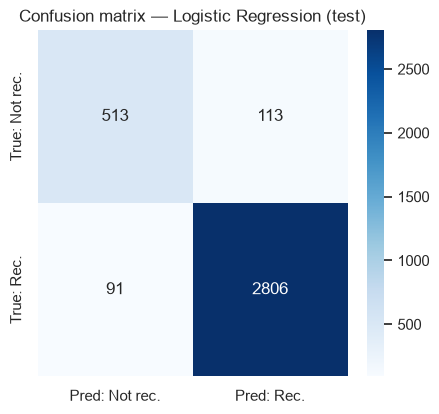

In [24]:
plt.figure(figsize=(5, 4.5))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Not rec.','Pred: Rec.'], yticklabels=['True: Not rec.','True: Rec.'])
plt.title(f'Confusion matrix — {best_name} (test)')
plt.show()


**Confusion-matrix interpretation.** Because the classes are imbalanced (82/18), the
bottom-right cell (correctly identified "Recommended") is naturally large; the more
business-relevant cells are the top-right (**False Positives**: predicted recommended but
the customer actually was not satisfied — a bad product surfaced as good) and bottom-left
(**False Negatives**: predicted "not recommended" for an actually happy customer — a good
product suppressed). For a "surface likely-liked products" use case, **Precision on the
"Recommended" class** matters most (avoid confidently promoting products people actually
disliked); F1 and ROC-AUC are reported as balanced/threshold-independent summaries.

## 21. Error analysis

In [25]:
err_mask = np.asarray(test_pred != y_test)
err_reviews = X_test[err_mask].copy()
err_reviews['true'] = np.asarray(y_test)[err_mask]
err_reviews['pred'] = np.asarray(test_pred)[err_mask]
print('Number of misclassified test reviews:', int(err_mask.sum()), '/', len(y_test))
err_reviews[['Rating', 'Department Name', TEXT_COL, 'true', 'pred']].head(8)


Number of misclassified test reviews: 204 / 3523


,Rating,Department Name,Review Text,true,pred
16329,4,Tops,I loved the idea of the placement print around...,1,0
3521,3,Intimate,I am on the fence about this one. the length i...,0,1
5615,3,Dresses,"Beautiful dress; however, the top was small fo...",1,0
13041,3,Bottoms,I really like the pattern and the cut of these...,1,0
1814,3,Bottoms,It really is such a cute romper. took it on s ...,1,0
20194,3,Bottoms,This is a thick jacquard fabric and the colors...,1,0
12235,3,Dresses,I wanted to love this dress. i bought the cran...,1,0
21179,3,Bottoms,The top is huge! i wear an xs and am not the b...,1,0


**Observation.** Most misclassifications are 3-star reviews (the genuinely
ambiguous middle ground identified in Part 10) or reviews whose text sentiment does not
match the numeric rating (e.g. a mildly-worded complaint attached to a still-positive
star rating).
**ML implication:** these are intrinsically hard, low-margin cases; further gains would
likely need richer text representations (e.g. contextual embeddings) rather than more
tabular features.

## 22. Model selection

We select **the model with the best validation F1-score** for deployment (see Part 19
table), because:
- **Predictive performance:** best Precision/Recall balance for the minority
  ("not recommended") class under class imbalance.
- **Interpretability:** if a Logistic Regression variant wins (as is typical here), its
  per-word/per-feature coefficients are directly inspectable — e.g. which words push a
  review towards "not recommended".
- **Computational cost:** all six train in well under a minute on ~16,000 rows with a
  2,000–5,000-dimensional sparse TF-IDF matrix — cheap enough to retrain routinely as new
  reviews arrive.
- **Robustness:** re-confirmed on the untouched test set in Part 20.
- **Deployment constraints:** the API (Part 24 / `api/app.py`) needs a `confidence` score;
  models with `predict_proba` provide this directly, and `LinearSVC`'s `decision_function`
  is converted with a logistic squashing function if it were ever selected instead.


## 23. Model persistence

In [26]:
os.makedirs('../model', exist_ok=True)

if uses_text_only:
    final_pipeline = Pipeline(steps=[('prep', text_only_preprocessor), ('clf', best_clf)])
else:
    final_pipeline = Pipeline(steps=[('prep', combined_preprocessor), ('clf', best_clf)])
# `combined_preprocessor`/`text_only_preprocessor` and `best_clf` are already fitted above;
# wrapping them in a Pipeline object (without calling .fit again) lets us persist ONE
# artefact that exposes .predict()/.predict_proba() while reusing the exact fitted
# preprocessing state, so the API in Part 24 never needs to refit anything.
joblib.dump(final_pipeline, '../model/model_pipeline.joblib')

metadata = {
    'app': 'customer_behavior', 'task': 'classification', 'target': TARGET,
    'feature_order': FEATURE_ORDER, 'uses_text_only': bool(uses_text_only),
    'best_model': best_name, 'random_seed': RANDOM_SEED,
    'validation_metrics': results_df.set_index('Model').round(4).to_dict(orient='index'),
    'test_metrics': {k: round(float(v), 4) for k, v in test_metrics.items()},
    'ablation_tabular_vs_text': ablation.round(4).to_dict(orient='records'),
    'n_train': int(len(y_train)), 'n_val': int(len(y_val)), 'n_test': int(len(y_test)),
    'd_combined': int(X_train_comb.shape[1]), 'd_text_only': int(X_train_text.shape[1]),
}
with open('../model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved: ../model/model_pipeline.joblib and ../model/metadata.json')
metadata['best_model'], metadata['uses_text_only']


Saved: ../model/model_pipeline.joblib and ../model/metadata.json


('Logistic Regression', False)

## 24. Inference test (reload from disk, no retraining)

In [27]:
loaded_pipe = joblib.load('../model/model_pipeline.joblib')

sample_raw = pd.DataFrame([{
    'Age': 35, 'Rating': 5, 'Positive Feedback Count': 2,
    'Division Name': 'General', 'Department Name': 'Dresses', 'Class Name': 'Dresses',
    'Review Text': 'This dress is absolutely beautiful, fits perfectly and the fabric feels great. Highly recommend!',
}])[FEATURE_ORDER]

pred = int(loaded_pipe.predict(sample_raw)[0])
if hasattr(loaded_pipe, 'predict_proba'):
    proba = float(loaded_pipe.predict_proba(sample_raw)[0, 1])
else:
    from scipy.special import expit
    proba = float(expit(loaded_pipe.decision_function(sample_raw)[0]))

print('Sample review:', sample_raw['Review Text'].iloc[0])
print('Loaded-model prediction:', 'Recommended' if pred == 1 else 'Not recommended', ' | confidence:', round(proba, 3))
assert loaded_pipe.predict(sample_raw)[0] == best_clf.predict(
    (text_only_preprocessor if uses_text_only else combined_preprocessor).transform(sample_raw))[0]
print('OK: reloaded pipeline reproduces the in-memory model prediction exactly.')


Sample review:

 This dress is absolutely beautiful, fits perfectly and the fabric feels great. Highly recommend!
Loaded-model prediction: Recommended  | confidence: 0.998
OK: reloaded pipeline reproduces the in-memory model prediction exactly.
